In [1]:
import numpy as np 
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import math            
import pickle                   
import os 
import gc
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
matplotlib.rcParams["figure.dpi"] = 150

In [2]:
trackDir = '/home/mwells5/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb_copy_m/tl_with_moduleID_07_28_2026/'
pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/plots/dfOfTruth.pkl"
flp = 0

with open(pklPath, 'rb') as file:
    # Reconstruct the Python object
    parquetData = pickle.load(file)

parquetData = parquetData[parquetData['source']!='sig']
# parquetData = parquetData[parquetData['source']=='bib_mm']

parquetData = parquetData[(parquetData['z-global'] >= 0) & (parquetData['z-global'] <= 13)]
parquetData = parquetData[(parquetData['adjusted_hit_time'] >= -.09) & (parquetData['adjusted_hit_time'] <= .15)]
parquetData = parquetData[parquetData['hit_time'] <= 0.03]

parquetData.reset_index()
# parquetData = parquetData.iloc[0:46031]
print(f"Total # of clusters: {len(parquetData)}")
print(f"keys parquets {parquetData.keys()} ")
# print(parquetData.head())
print("calc1_min: ", parquetData['p_calc1'].min())
print("hit_time min: ", parquetData['hit_time'].min())
print("hit_time max: ", parquetData['hit_time'].max())


Total # of clusters: 1807
keys parquets Index(['x-entry', 'y-entry', 'z-entry', 'n_x', 'n_y', 'n_z', 'number_eh_pairs',
       'y-local', 'z-global', 'pt', 'hit_time', 'PID', 'cotAlpha', 'cotBeta',
       'y-midplane', 'x-midplane', 'adjusted_hit_time',
       'adjusted_hit_time_30ps_gaussian', 'adjusted_hit_time_60ps_gaussian',
       'source', 'eta', 'R', 'q', 'm', 'scalePion', 'p_calc1', 'p_calc2',
       'p_calc3', 'betaGamma', 'pathLength', 'EHperMicron'],
      dtype='object') 
calc1_min:  8.99984831331369e-05
hit_time min:  0.01012
hit_time max:  0.03


In [3]:
trackData = pd.DataFrame()
trackdata_list = []

trackHeader = ["cota", "cotb", "p", "flp", "ylocal", "zglobal", "pt", "t", "hit_pdg", "moduleID"]

for file in os.listdir(trackDir):
    if "bib_mm" in file:
        trackdata_list.append(pd.read_csv(f"{trackDir}{file}", sep=' ', names=trackHeader))
    elif "bib_mp" in file: 
        trackdata_list.append(pd.read_csv(f"{trackDir}{file}", sep=' ', names=trackHeader))

trackData = pd.concat(trackdata_list)
del trackdata_list
gc.collect()

trackData['adjusted_hit_time'] = trackData['t']-1e6*np.sqrt(trackData['zglobal']**2+30**2)/299792458

trackData = trackData[(trackData['zglobal'] >= 0) & (trackData['zglobal'] <= 13)]
trackData = trackData[(trackData['adjusted_hit_time'] >= -.09) & (trackData['adjusted_hit_time'] <= .15)]
#trackData = trackData[(trackData['moduleID'] == 5)]
trackData = trackData[trackData['t'] <= 0.03]

trackData.reset_index()

print(f"length of tracklist {len(trackData)}")
print(f"tracklist keys {trackData.keys()}")

print(trackData['p'].min())
print(trackData['p'].max())

print(trackData['t'].min())
print(trackData['t'].max())

length of tracklist 1936
tracklist keys Index(['cota', 'cotb', 'p', 'flp', 'ylocal', 'zglobal', 'pt', 't', 'hit_pdg',
       'moduleID', 'adjusted_hit_time'],
      dtype='object')
6e-05
2.62727
0.01012
0.03


In [4]:
def cut_tracks(df):
    df = df[(df['zglobal'] >= 0) & (df['zglobal'] <= 13)]
    df = df[(df['adjusted_hit_time'] >= -.09) & (df['adjusted_hit_time'] <= .15)]
    df = df[(df['moduleID'] == 1)]
    df.reset_index()
    return df

In [4]:
def percent_reduction(tracks, parquets):
    return math.trunc(1e4*((tracks.shape[0])-(parquets.shape[0]))/tracks.shape[0])/100

print(percent_reduction(trackData, parquetData))

6.66


In [4]:
from matplotlib.colors import LinearSegmentedColormap

hex_palette = [
    "#ff0000", "#ff5f00", "#ffbf00", "#dfff00", 
    "#7fff00", "#1fff00", "#00ff3f", "#00ff9f", 
    "#00feff", "#009fff", "#003fff", "#1f00ff", 
    "#7f00ff", "#df00ff", "#ff00bf", "#ff005f"
]

# 2. Create the segmented colormap with 16 distinct levels
cmap_16 = LinearSegmentedColormap.from_list("palette_16", hex_palette, N=16)

In [10]:
def make_scatterplot_t(tracks_df):

    #cut_tracks(tracks_df)
    
    x_l = (tracks_df['zglobal']%13)*40 # 1mm = 40px
    x_l = x_l.to_numpy()
    x_l = x_l.astype(int)
    
    y_l = (((tracks_df['ylocal'])+8.5)*40)-160 # changes range from 0 to 13 and convert to px
    y_l = y_l.to_numpy()
    y_l = y_l.astype(int)

    momenta = tracks_df['p']
    momenta = momenta.to_numpy()

    times = tracks_df['t']
    times = times.to_numpy()

    module = tracks_df['moduleID']
    module = module.to_numpy()

    hit_min = np.floor(tracks_df['adjusted_hit_time'].min()*100)/100
    hit_max = np.ceil(tracks_df['adjusted_hit_time'].max()*100)/100

    if (tracks_df['moduleID'].max() == tracks_df['moduleID'].min()):
        number = tracks_df['moduleID'].iat[0]
    else:
        number = 'N/A'

    fig, ax = plt.subplots(figsize=(6.7,6),dpi=200)
    im = ax.scatter(y_l, x_l, c=module, cmap=cmap_16, marker='.', s=15, vmin=1, vmax=16)
                    #norm=mcolors.LogNorm(vmin=1e-5, vmax=10))

    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    fig.colorbar(im, cax=cax, location='right',label='module number')
    ax.set_title(f"Scatterplot from tracks, module {number}")

    ax.set_xlim(0,520)
    ax.set_ylim(0,520)
    ax.set_xlabel("x-local [px]")
    ax.set_ylabel("y-local [px]")
    ax.set_box_aspect(1)
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(20))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))
    plt.figtext(0.155,0.177, f"Number of hits: {tracks_df.shape[0]}\n{hit_min} < Adj. hit time < {hit_max}", fontsize=12, 
                bbox=dict(facecolor='white', alpha=0.6))
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

    plt.tight_layout(pad=3.5)
    #ax.invert_yaxis()
    ax.invert_xaxis()
    fig.canvas.draw()

def make_scatterplot_p(parquets_df):

    #cut_tracks(tracks_df)
    
    x_l = (parquets_df['z-global']%13)*40 # 1mm = 40px
    x_l = x_l.to_numpy()
    x_l = x_l.astype(int)
    
    y_l = (((parquets_df['y-local'])+8.5)*40) # changes range from 0 to 13 and convert to px
    y_l = y_l.to_numpy()
    y_l = y_l.astype(int)

    momenta = parquets_df['p_calc2']
    momenta = momenta.to_numpy()
    #print(momenta.max)

    times = parquets_df['hit_time']
    times = times.to_numpy()

    hit_min = np.floor(parquets_df['adjusted_hit_time'].min()*100)/100
    hit_max = np.ceil(parquets_df['adjusted_hit_time'].max()*100)/100

    fig, ax = plt.subplots(figsize=(6.7,6),dpi=200)
    im = ax.scatter(y_l, x_l, c=times, cmap='Blues', marker='.', s=15)
                    #norm=mcolors.LogNorm(vmin=1e-5, vmax=10))

    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    fig.colorbar(im, cax=cax, location='right', label='hit time [ns] (not adjusted!)')
                 #label='momentum [GeV]')
    ax.set_title(f"Scatterplot from parquets")
    
    ax.set_xlim(0,520)
    ax.set_ylim(0,520)
    ax.set_xlabel("x-local [px]")
    ax.set_ylabel("y-local [px]")
    ax.set_box_aspect(1)
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(20))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))
    plt.figtext(0.155,0.177, f"Number of hits: {parquets_df.shape[0]}\n{hit_min} < Adj. hit time < {hit_max}", fontsize=12,
                #\nPixelAV data reduction: {reduction(trackData, parquetData)}%"
                bbox=dict(facecolor='white', alpha=0.6))
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    #ax.invert_yaxis()
    plt.tight_layout(pad=3.5)
    fig.canvas.draw()



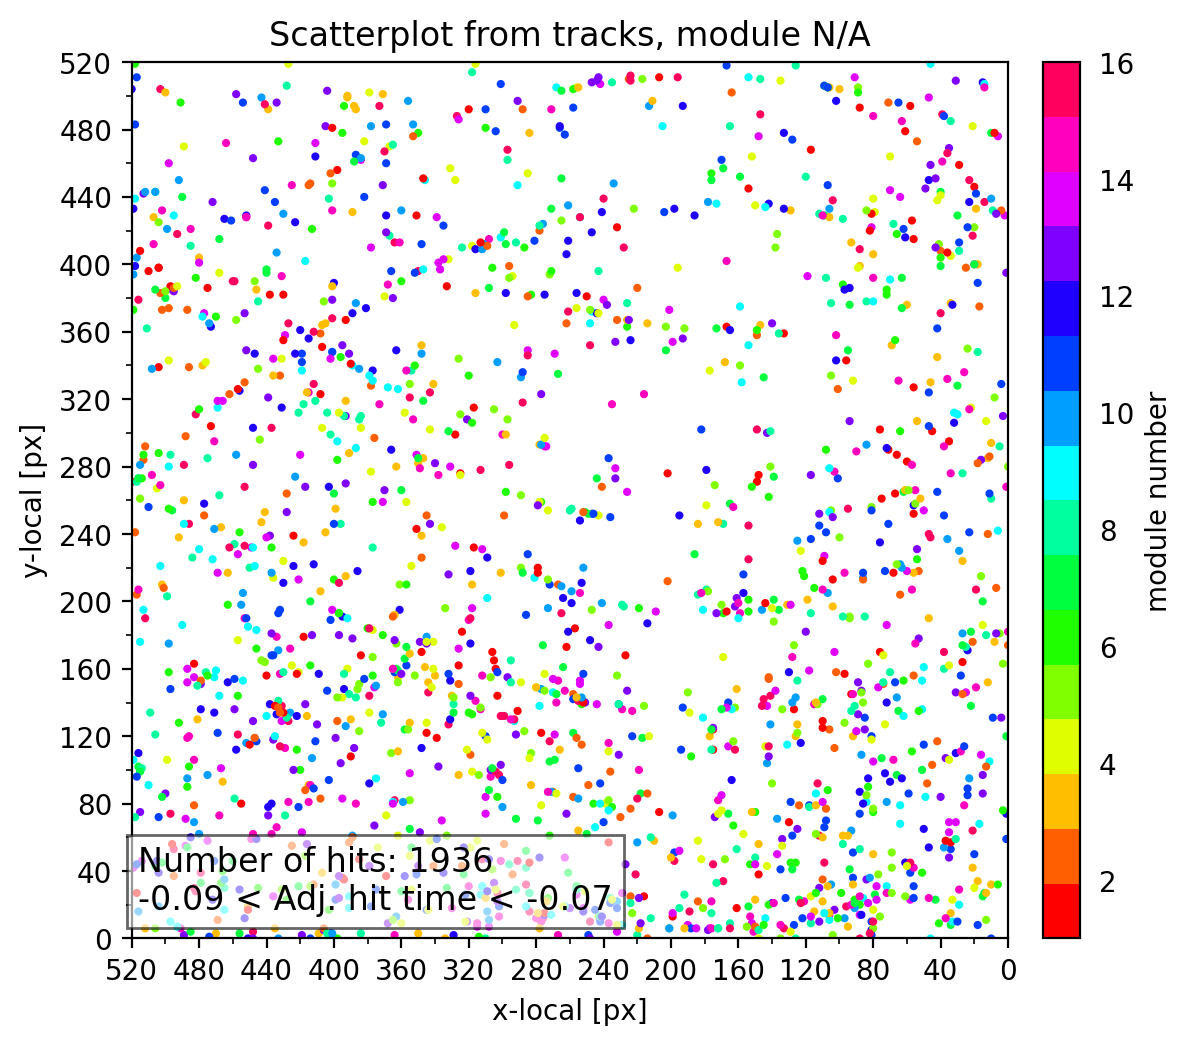

In [11]:
make_scatterplot_t(trackData)

# max time for all tracks = 50.5 seconds


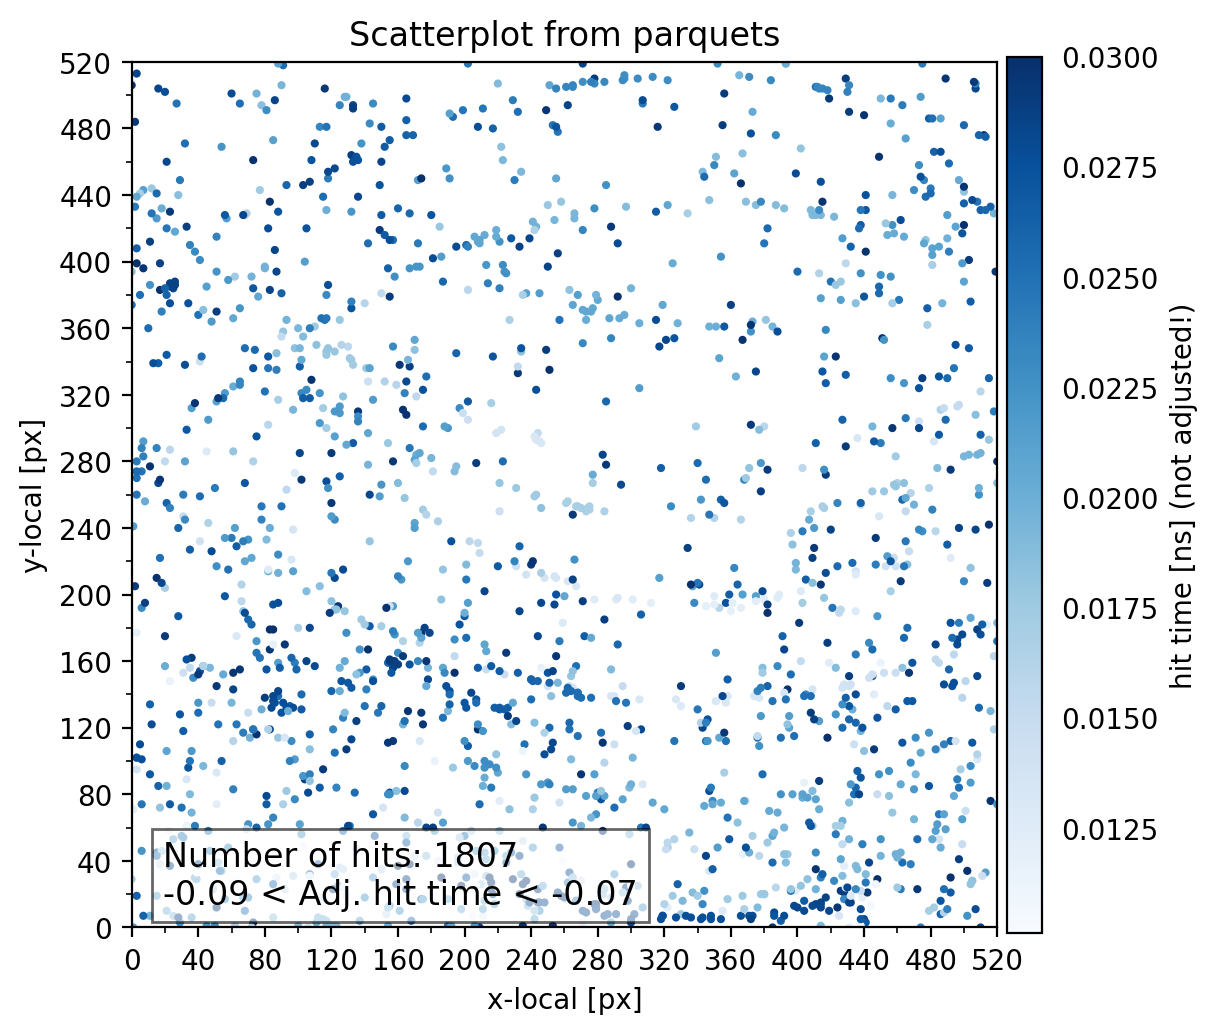

In [10]:
make_scatterplot_p(parquetData)

# max time for all events = 100 seconds

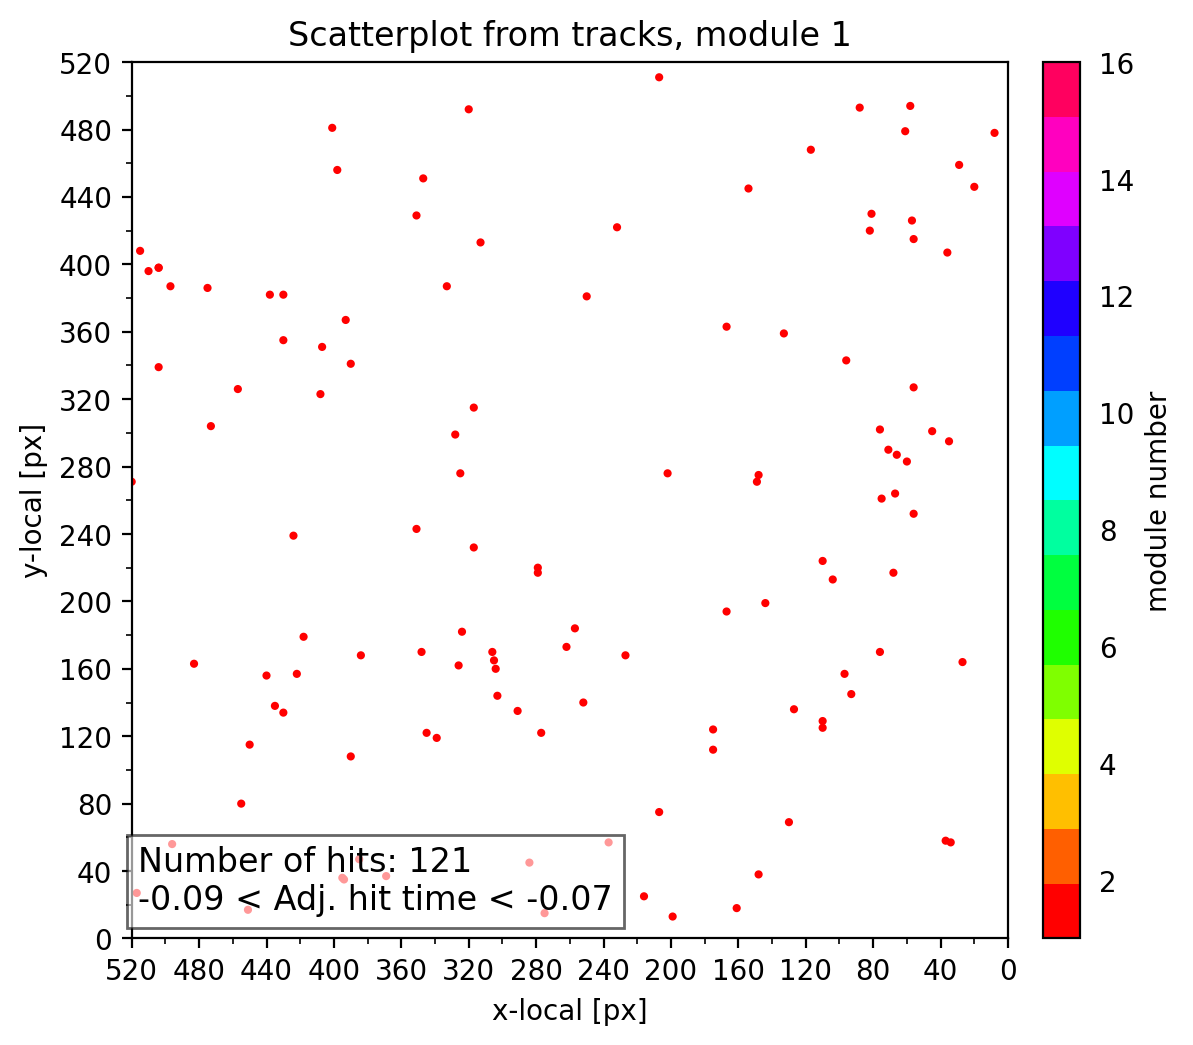

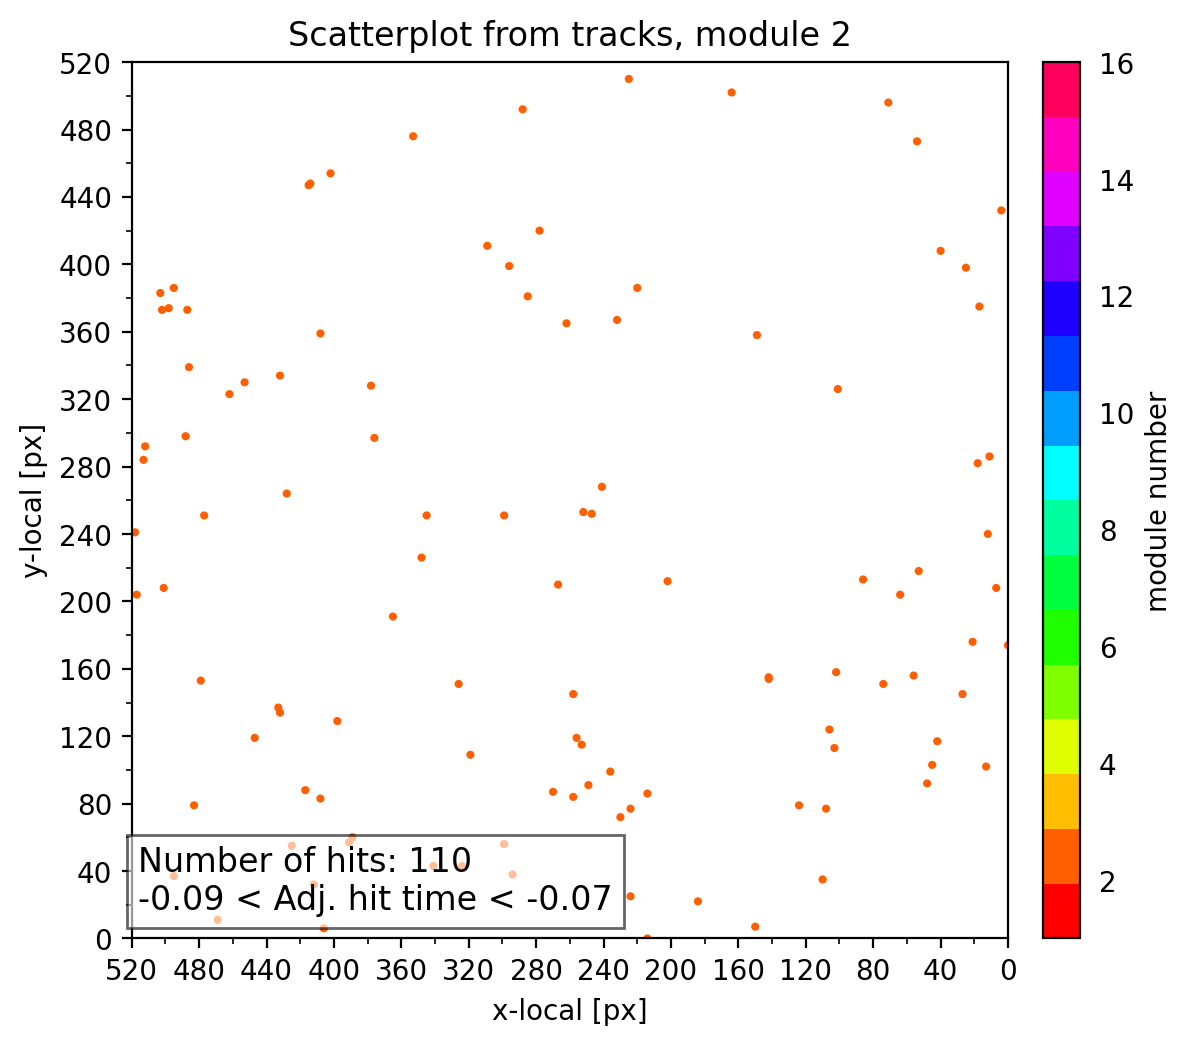

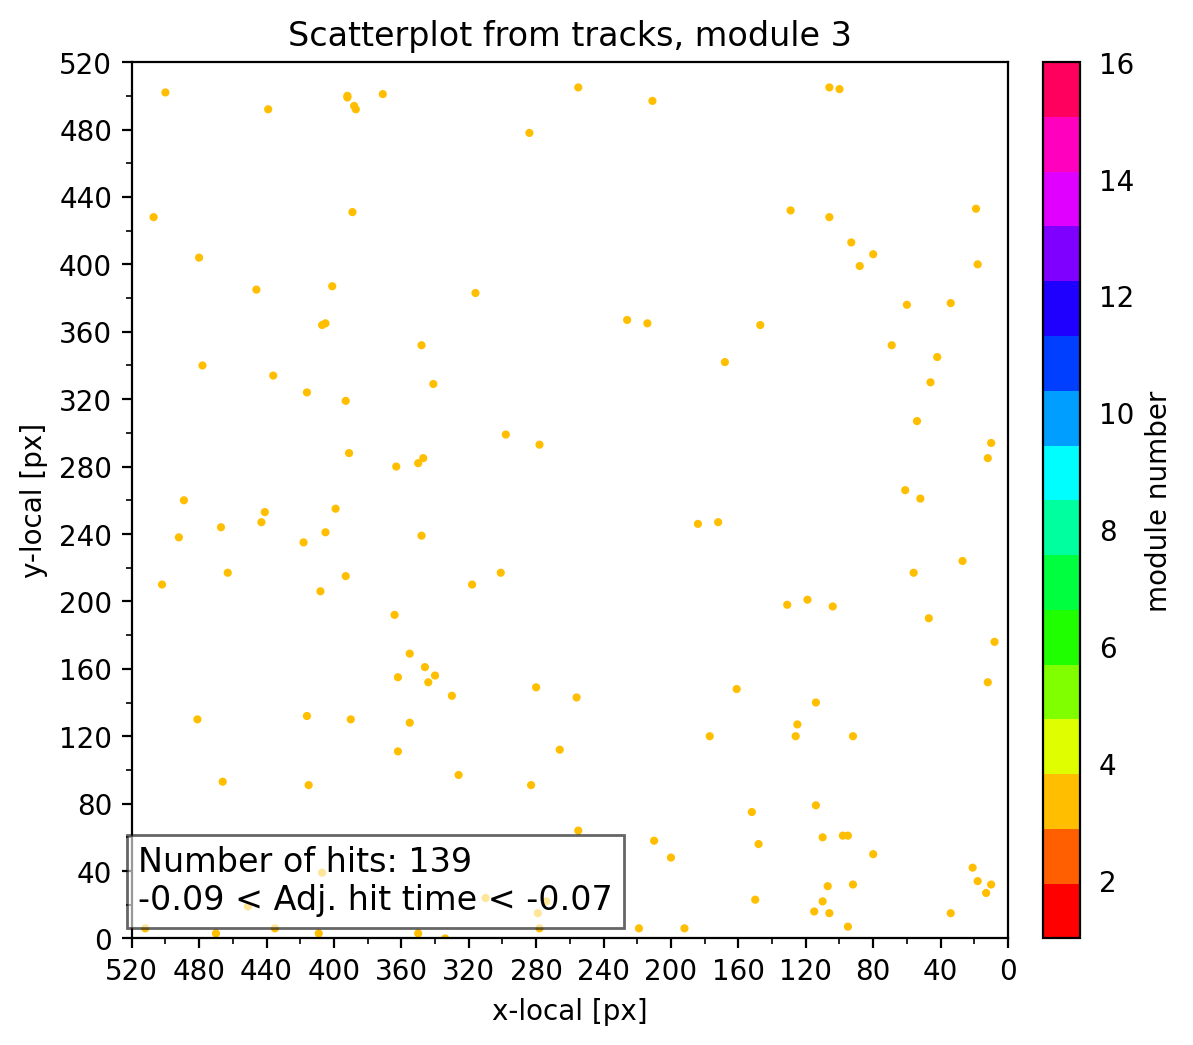

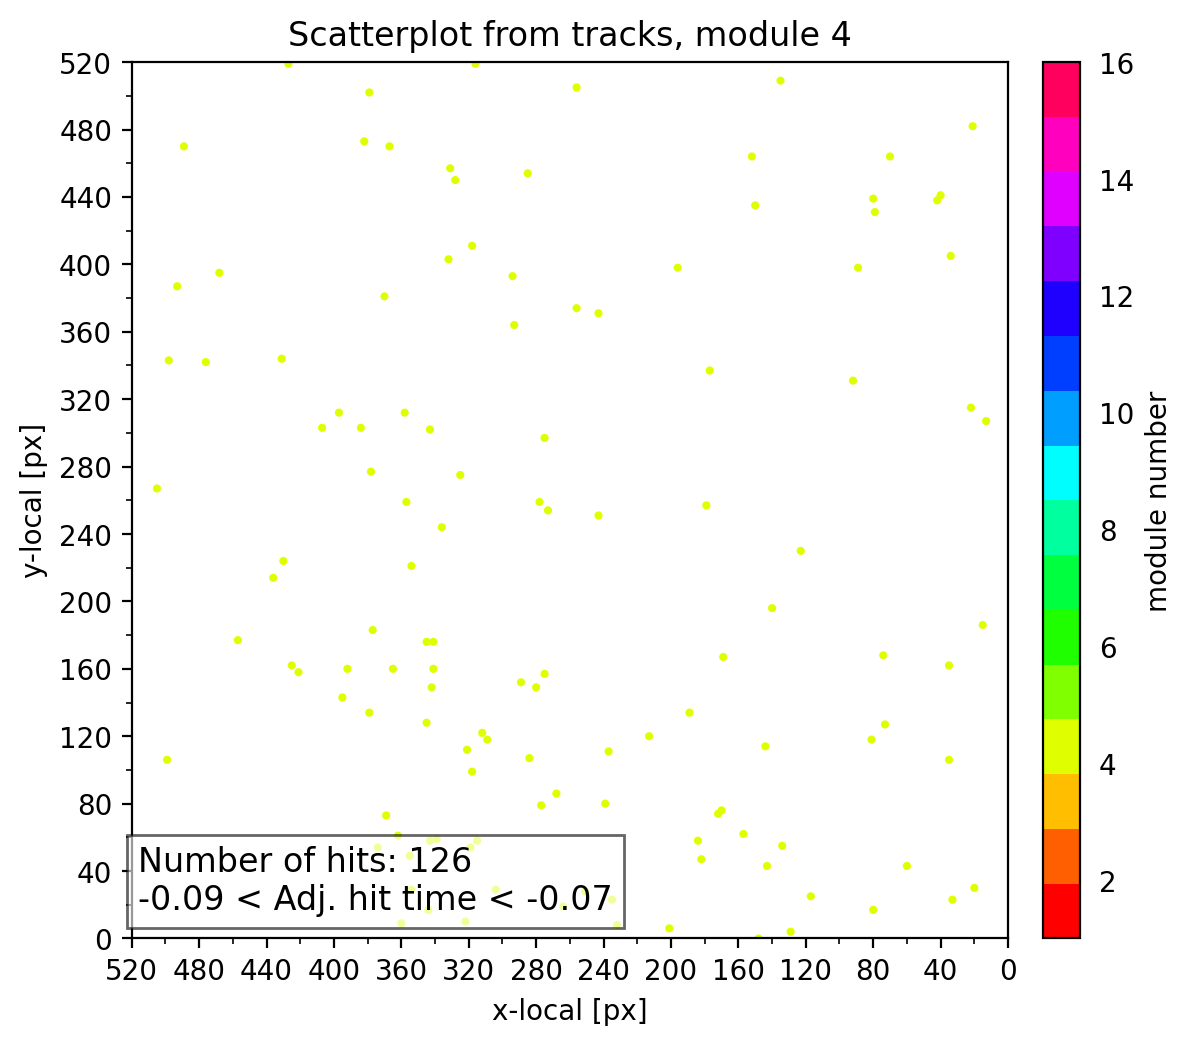

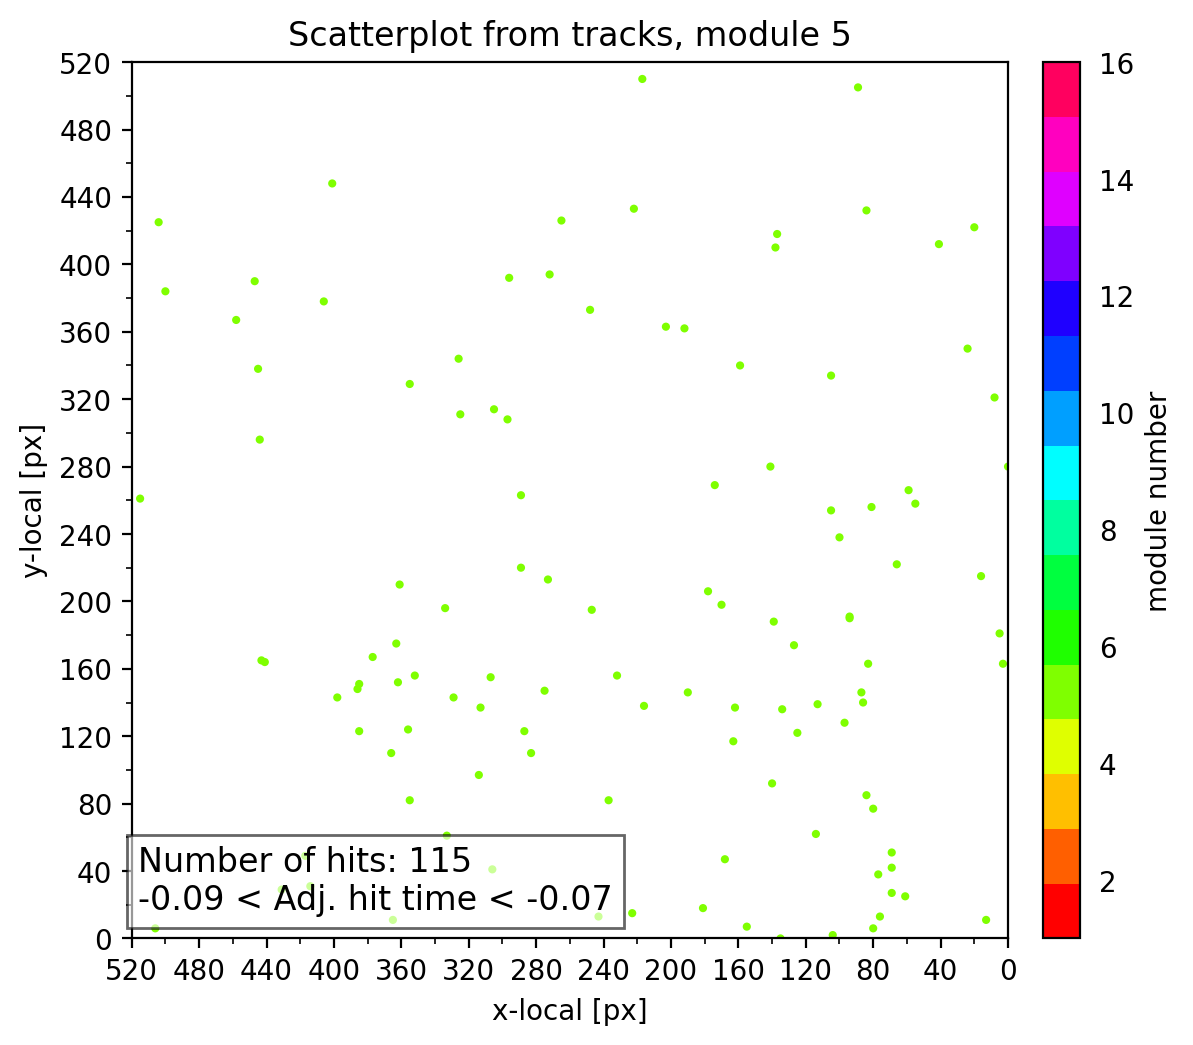

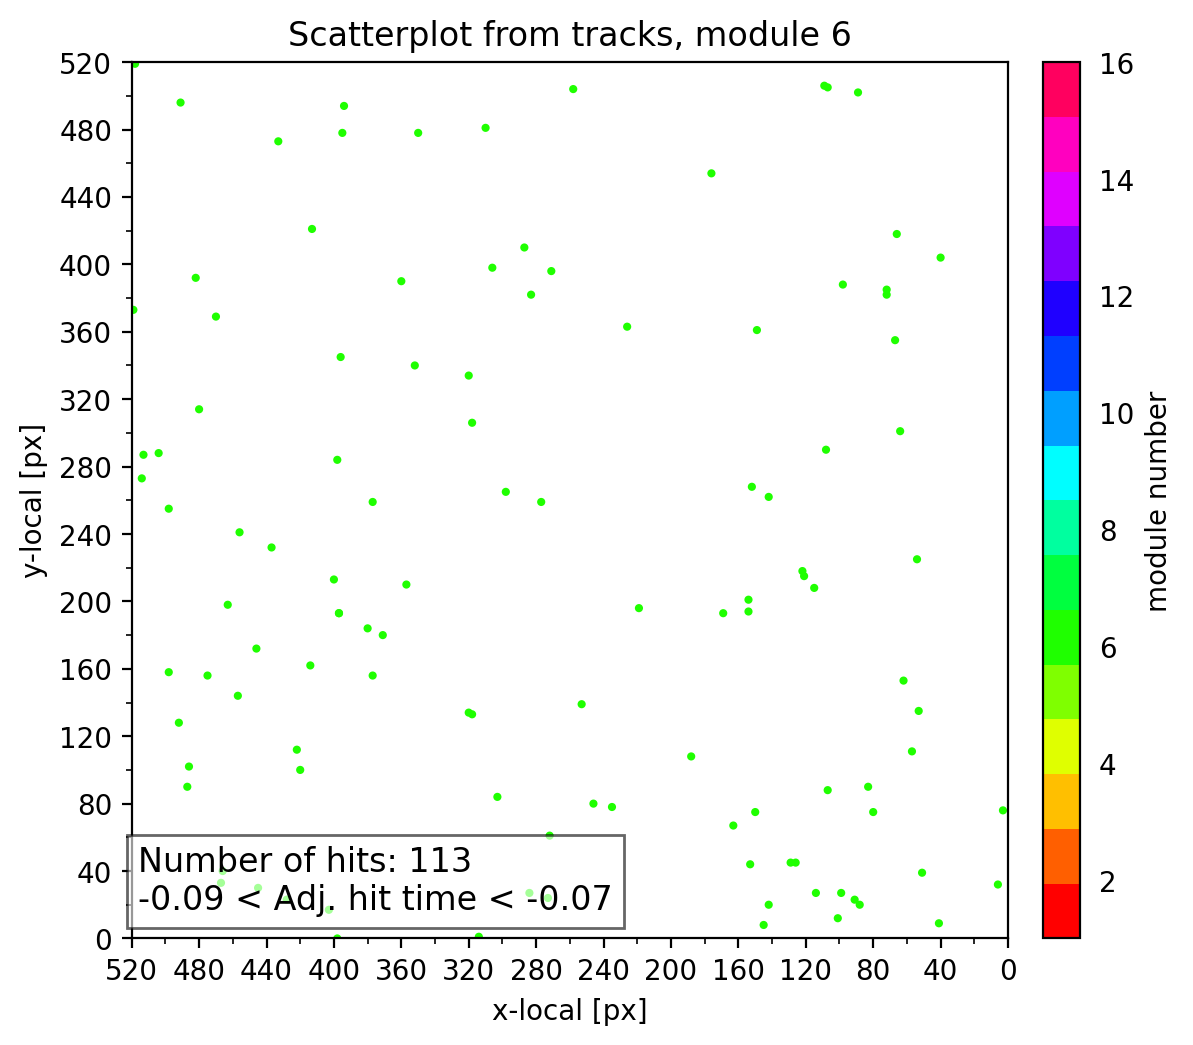

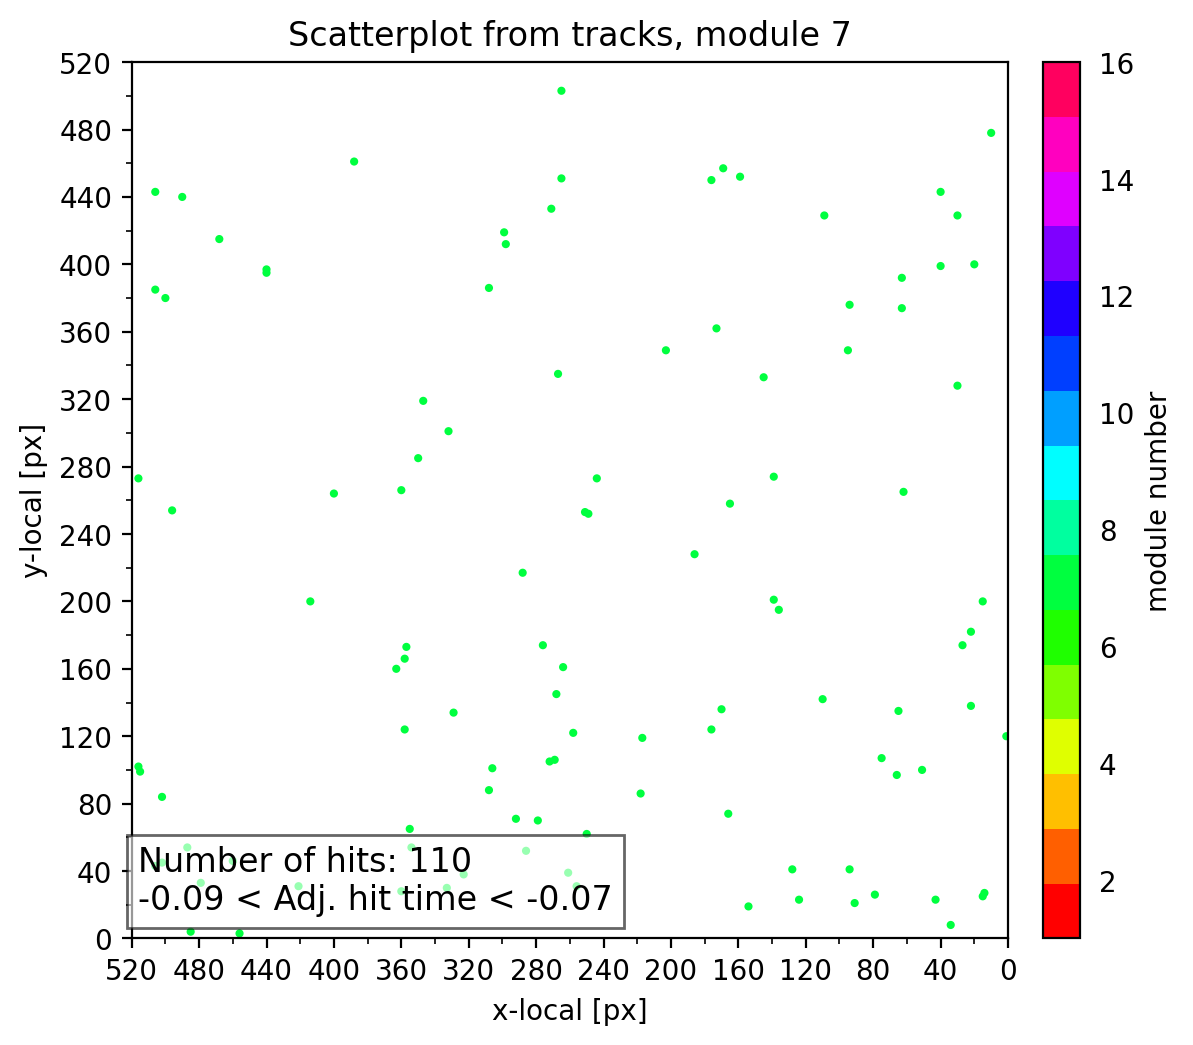

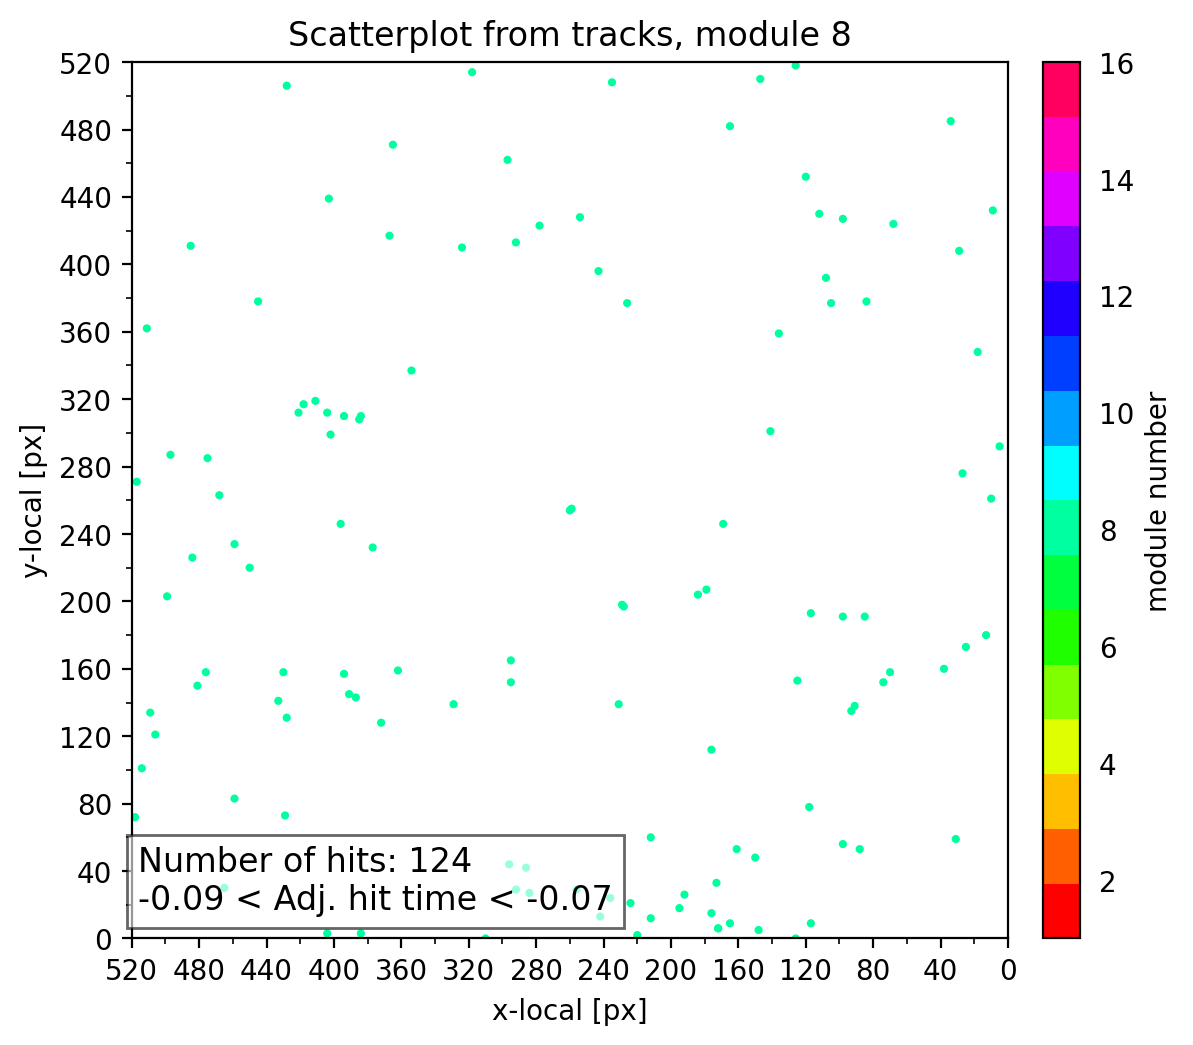

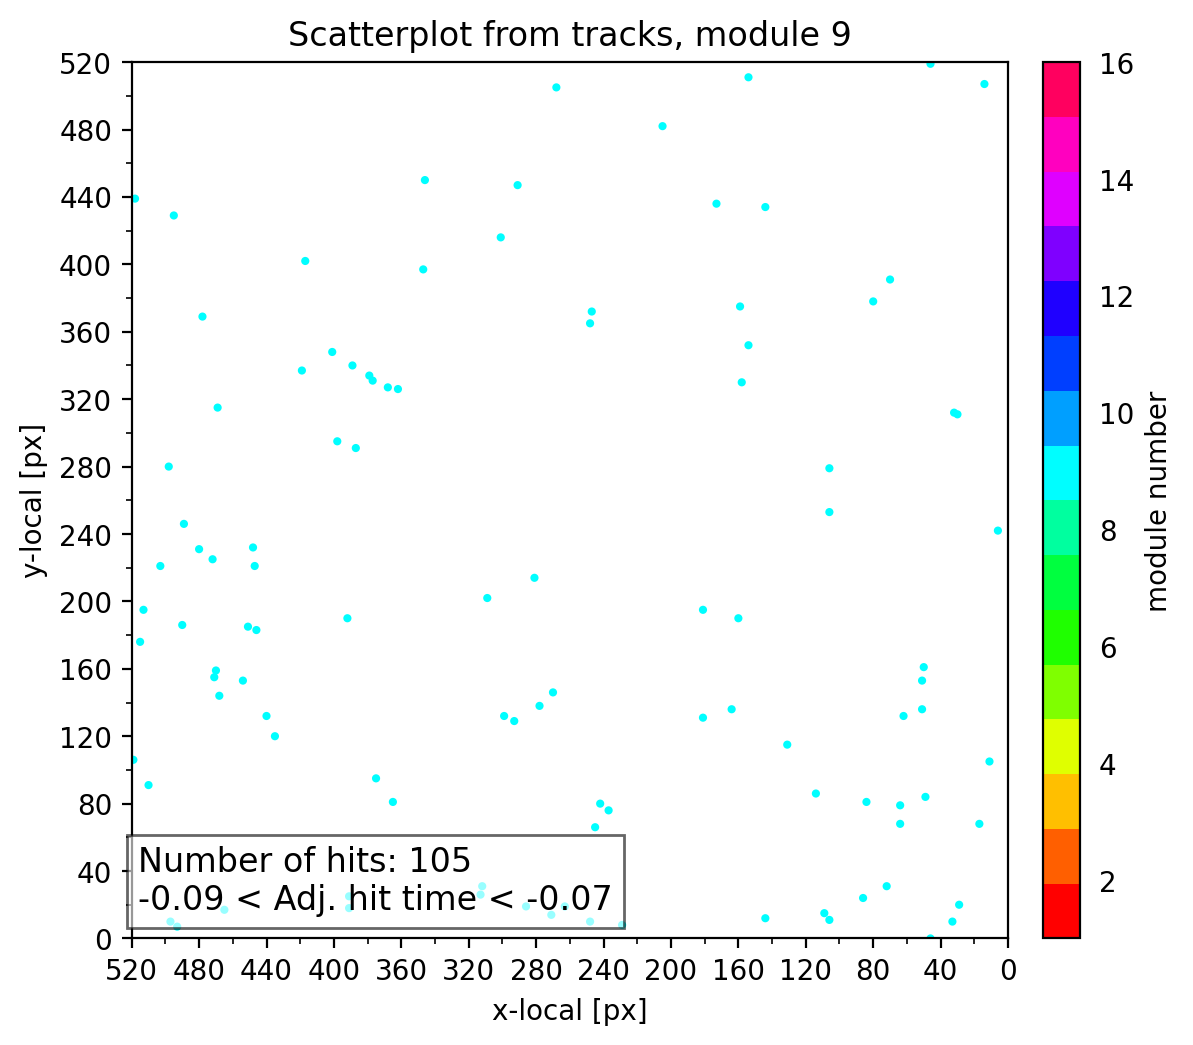

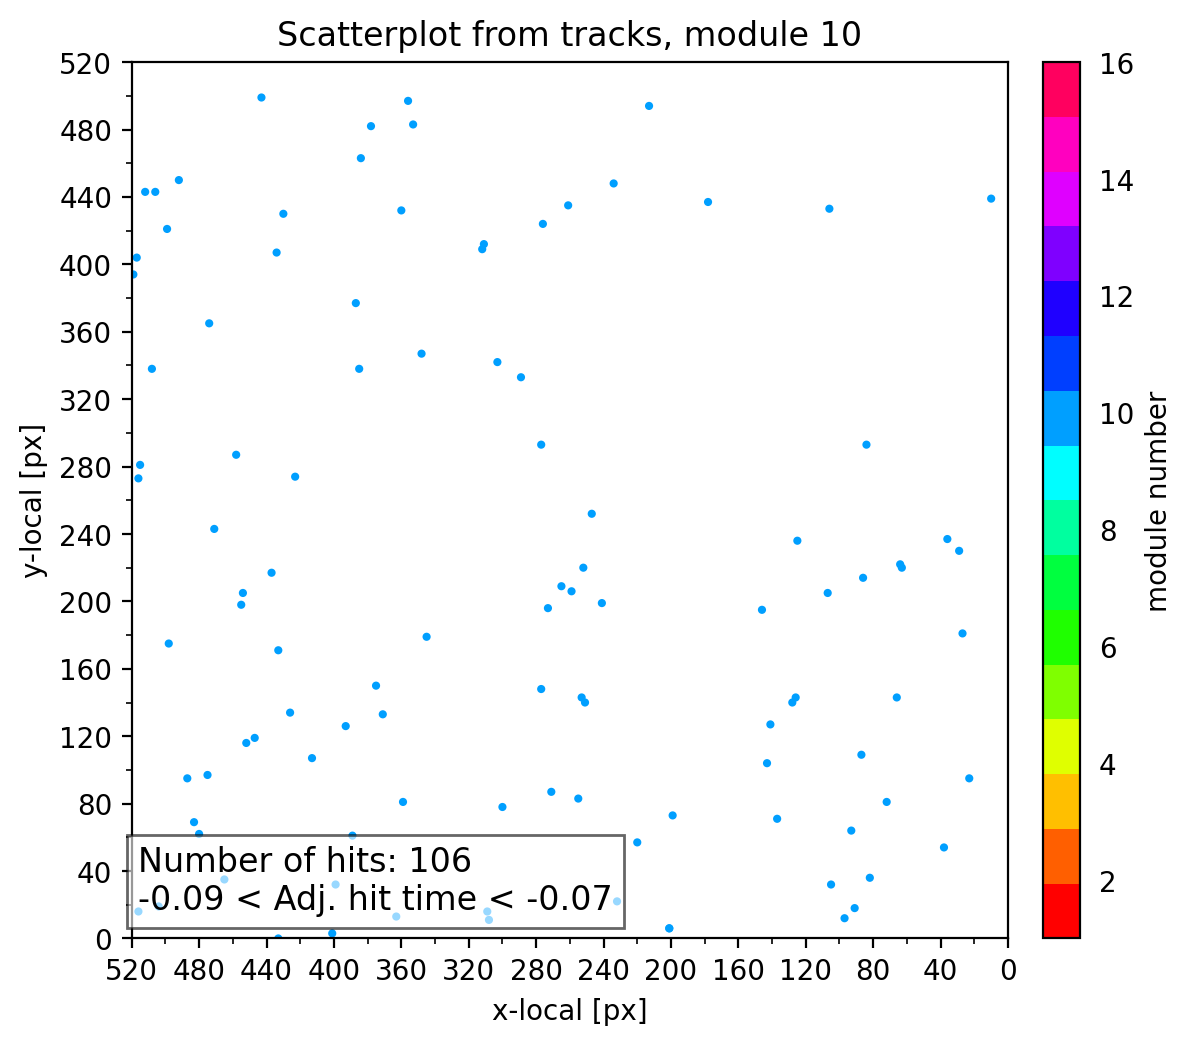

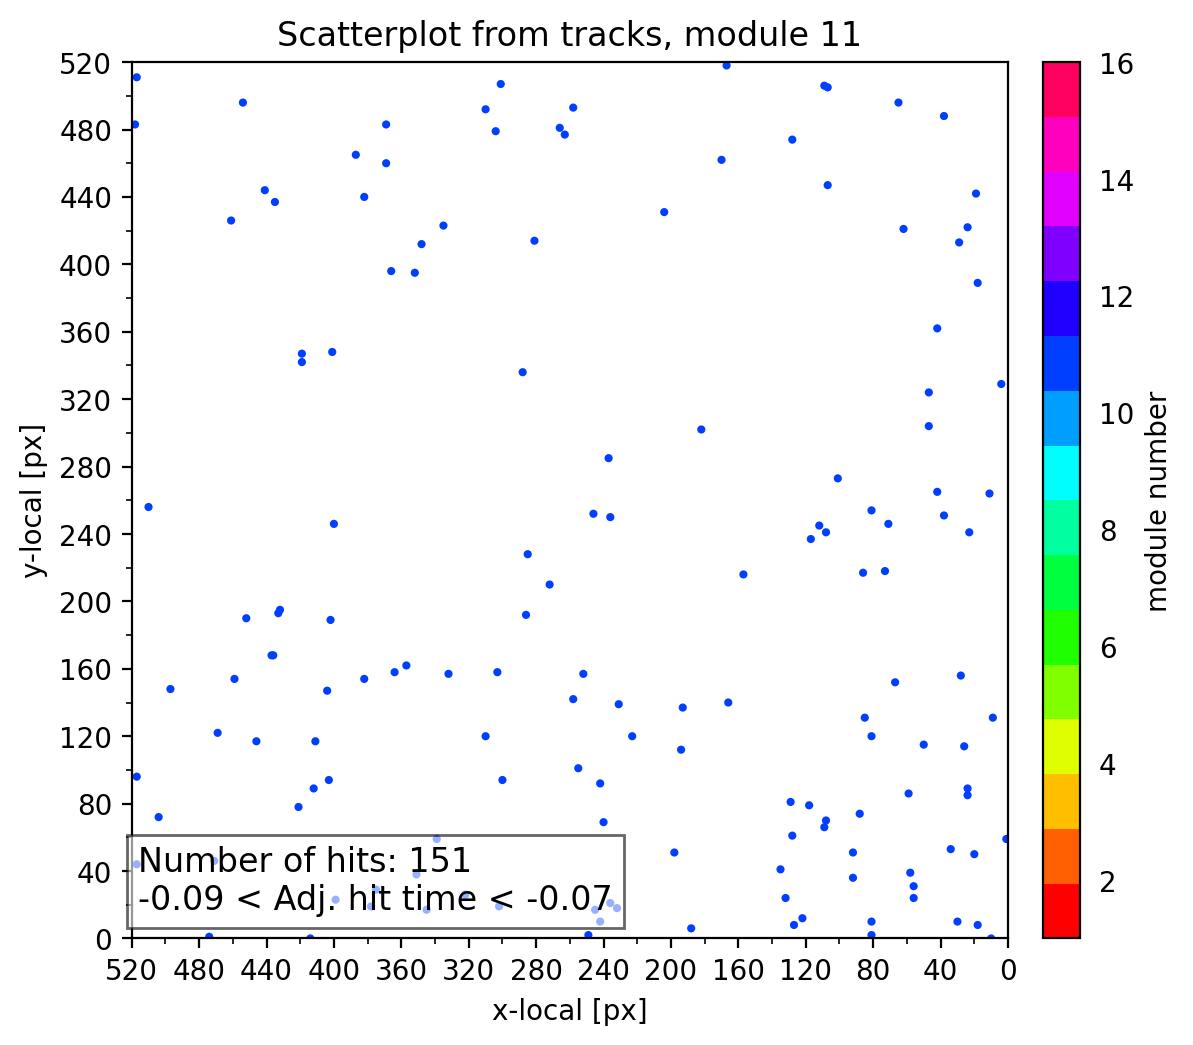

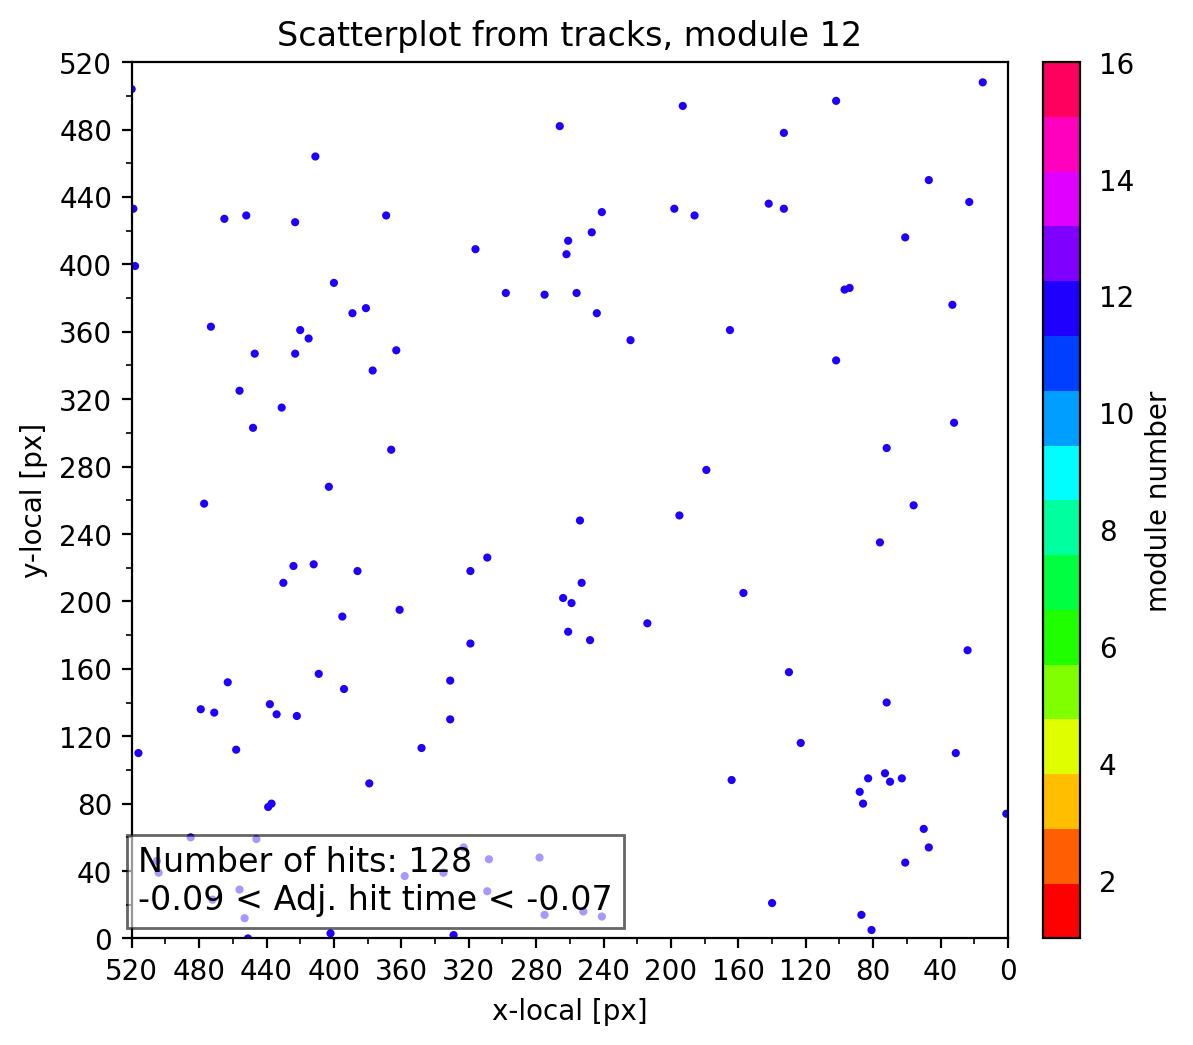

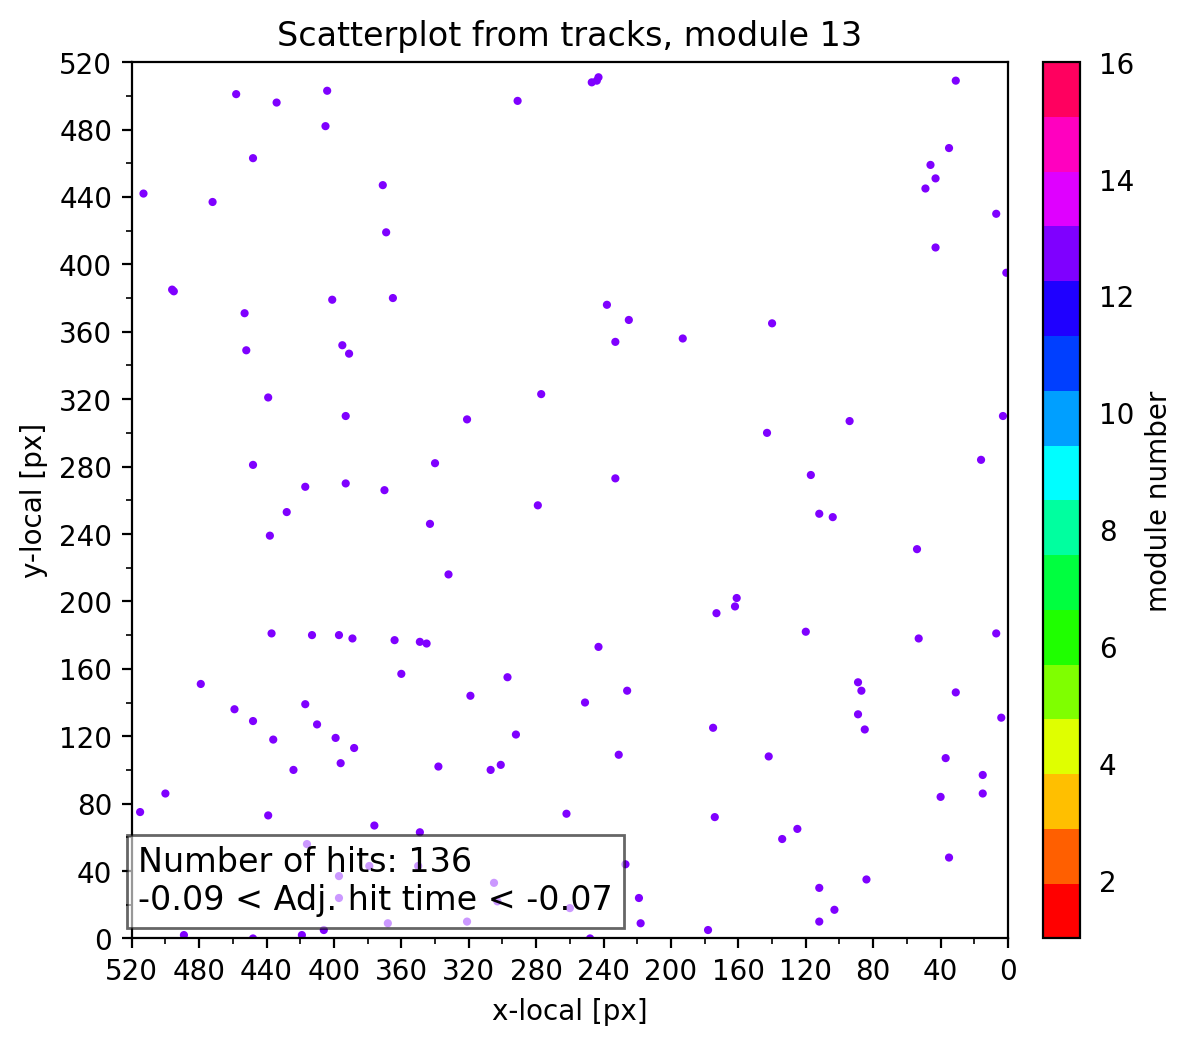

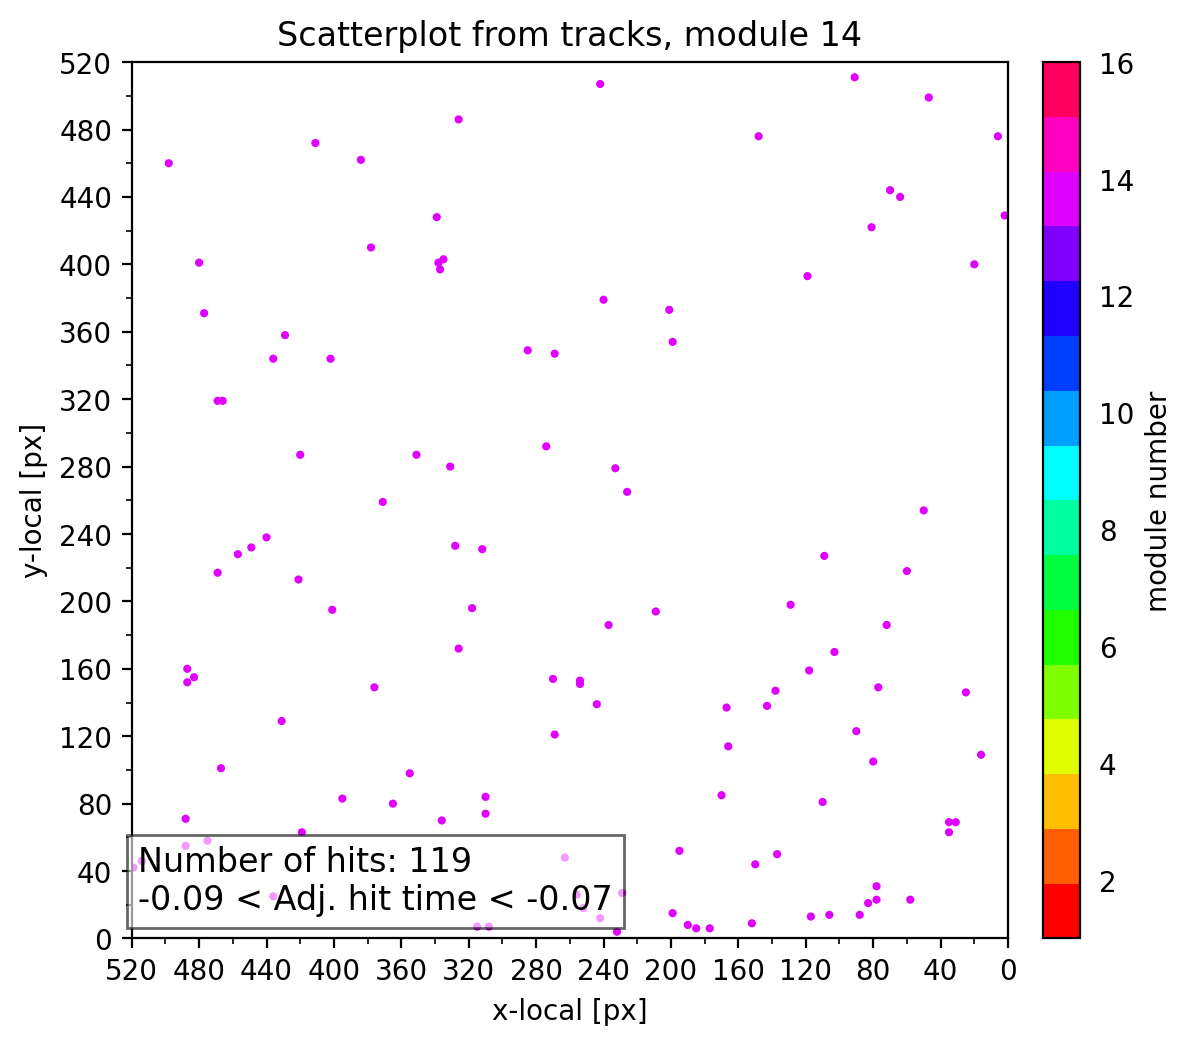

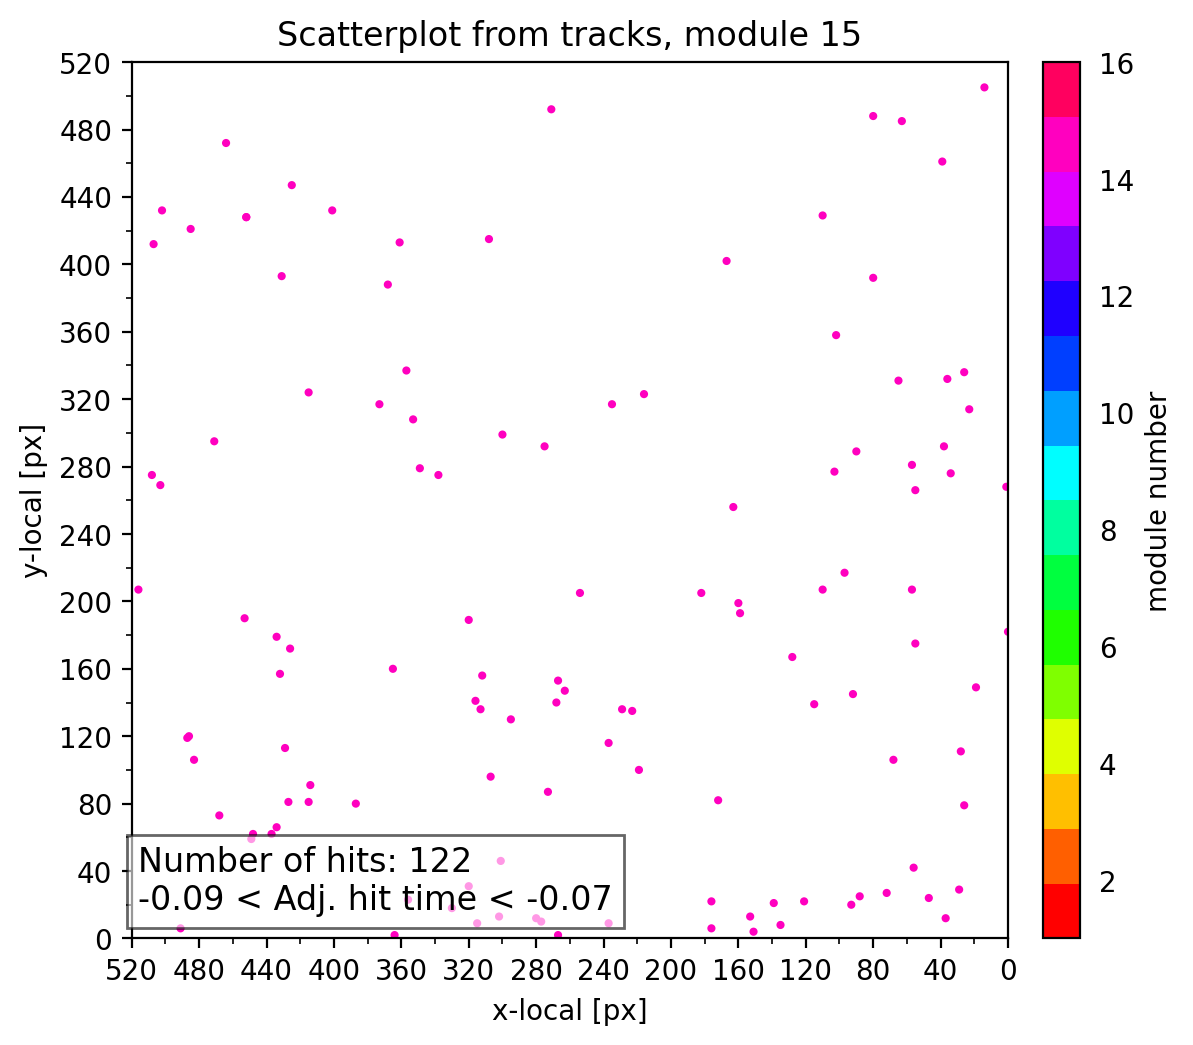

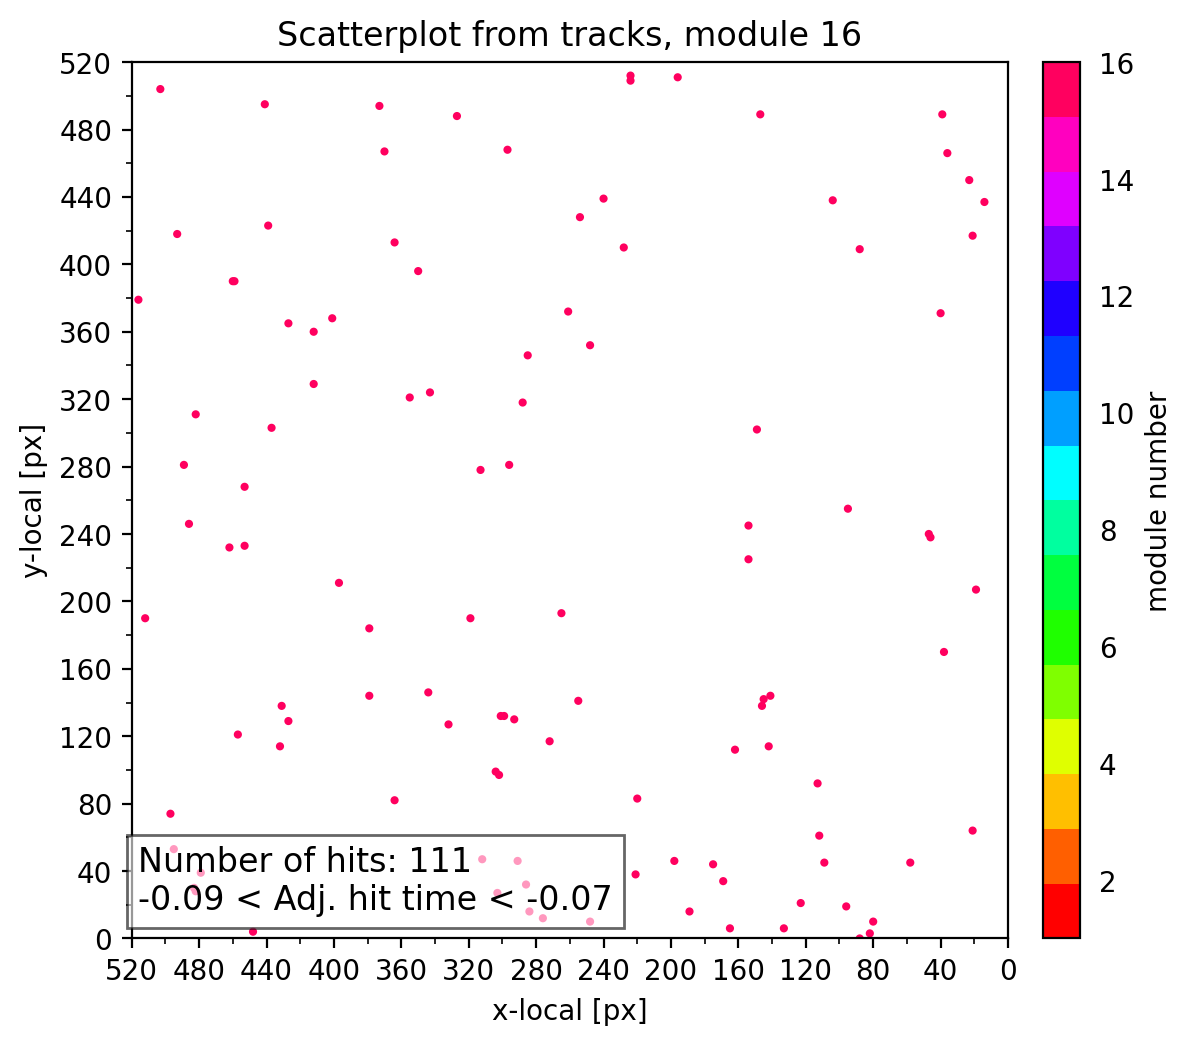

In [12]:

def scan_all_modules(tdf):
    i=0
    temp = pd.DataFrame()
    for i in range(1,17):
        temp = tdf[tdf['moduleID']==i]
        make_scatterplot_t(temp)

scan_all_modules(trackData)
